# **Telco Churn - EDA**

Dando continuidade à Análise Exploratória de Dados (EDA), este ambiente foca na prototipagem e validação de modelos de Machine Learning para o case da **Telecom X** (Hackathon Alura).

Nesta etapa, transformamos os insights obtidos anteriormente em um sistema de decisão. O objetivo é criar um classificador binário capaz de distinguir, com alta precisão, clientes propensos ao cancelamento.

---

**Roteiro Técnico:**

* **Data Prep:** Carregamento dos dados processados (Parquet) e separação de treino/teste.
* **Modelagem:** Treinamento de algoritmos (Baseline vs Modelos Avançados).
* **Avaliação de Performance:** Análise de métricas focadas no desbalanceamento de classes (Recall, Precision, Recall e AUC-PR).

O resultado esperado é um modelo serializado pronto para ser consumido por uma API ou pipeline de produção.

In [52]:
# Bibliotecas

# Tipagem
from typing import Union, Optional

# Contagem
from collections import Counter

# Utilitários
from pathlib import Path


# Manipulação de Dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn

# Base
from sklearn.base import ClassifierMixin

# Utilitários
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError

# Pré-processamento
# Encoding
from sklearn.preprocessing import (
    OneHotEncoder,
    FunctionTransformer
)

# Scaling
from sklearn.preprocessing import RobustScaler

# Imputação
from sklearn.impute import (
    SimpleImputer
)

# Split de Dados
from sklearn.model_selection import train_test_split

# Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Cross Validation
from sklearn.model_selection import (
    cross_validate
)

# Estratégia de fold
from sklearn.model_selection import StratifiedKFold

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    recall_score,
    precision_score,
    classification_report,
    average_precision_score,
    fbeta_score
)

# Visualizações do sklearn
from sklearn.metrics import(
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Otimização de Hiperparâmetros
from optuna import create_study, trial

# joblib
import joblib

In [2]:
# Considerando que este notebook está em ml/notebooks/
PROJECT_ROOT = Path.cwd().parents[1]

RAW_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "processed"

PLOTS_DIR = PROJECT_ROOT / "ml" / "plots"

PROCESSED_DATA_PATH = PROCESSED_DATA_DIR / "telecom_churn_processed.parquet"

MODEL_DATA_DIR = PROJECT_ROOT / "ml" / "models"
MODEL_DATA_PATH = MODEL_DATA_DIR / "modelo_churn.joblib"

In [3]:
# Constantes
RANDOM_SEED = 25

## **Modelagem**

### **Separação features (X) e target (y)**

In [4]:
# Carrega os dados processados
telecom_processed = pd.read_parquet(PROCESSED_DATA_PATH, engine='pyarrow')

In [5]:
# Verifica se os dados foram carregados corretamente
telecom_processed.sample(5)

,genero,idoso,parceiro,dependentes,tempo_contrato_meses,servico_telefone,linhas_multiplas,tipo_internet,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,cobranca_digital,metodo_pagamento,cobranca_mensal,cobranca_total,churn
2455,mulher,0,0,0,5,1,nao,fibra,nao,sim,nao,sim,nao,sim,mensal,1,cheque_eletronico,89.349998,461.700012,1
1691,homem,0,1,1,60,1,nao,sem_internet,sem_internet,sem_internet,sem_internet,sem_internet,sem_internet,sem_internet,dois_anos,0,cartao_credito_automatica,19.650000,1161.750000,0
1749,homem,1,0,0,52,1,sim,fibra,nao,sim,sim,sim,sim,sim,mensal,1,cheque_eletronico,110.750000,5832.000000,0
2666,homem,0,0,1,66,1,nao,dsl,nao,sim,sim,sim,sim,sim,dois_anos,1,cartao_credito_automatica,79.500000,5196.100098,0
237,homem,0,1,0,18,1,sim,fibra,nao,nao,nao,nao,nao,nao,mensal,1,cheque_eletronico,73.150002,1305.949951,0


In [6]:
# Separa features e target garantindo independência de memória
X = telecom_processed.drop(columns=['churn']).copy()
y = telecom_processed['churn'].copy()

### **Separação treino e teste**

Vamos começar separando os dados em conjuntos de treino e teste. O conjunto de treino será utilizado para treinar os modelos, enquanto o conjunto de teste será usado para avaliar o desempenho dos modelos treinados. Vamos utilizar a função `train_test_split` do scikit-learn para fazer essa separação. Vamos definir o tamanho do conjunto de teste como 20% dos dados e utilizar uma semente aleatória para garantir a reprodutibilidade dos resultados. Vamos também garantir que a variável alvo Churn esteja balanceada entre os conjuntos de treino e teste, utilizando o parâmetro `stratify` na função `train_test_split`.

In [7]:
# Separando os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, # 30% dos dados para teste
    random_state=RANDOM_SEED, # Semente para reprodutibilidade
    stratify=y # Mantém a proporção de classes no split
)

# Exibe as dimensões dos conjuntos de treino e teste
print(f"Dimensões do conjunto de treino: {X_train.shape}, {y_train.shape}")
print(f"Dimensões do conjunto de teste: {X_test.shape}, {y_test.shape}")

Dimensões do conjunto de treino: (4930, 19), (4930,)
Dimensões do conjunto de teste: (2113, 19), (2113,)


### **Seleção de modelos**

#### **Funções auxiliares**

In [8]:
# Função para criar figuras do matplotlib
def _ensure_fig_ax(ax: Optional[plt.Axes],
                   figsize=(8, 6)) -> tuple[plt.Figure, plt.Axes]:
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
    return fig, ax

In [9]:
# Função auxiliar para salvar figuras
def _maybe_save(fig: plt.Figure, save_path: Optional[Union[str, Path]]) -> None:
    if save_path:
        path = Path(save_path)
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, bbox_inches="tight", dpi=300)

In [10]:
# Função para plotar a matriz de confusão a partir de um estimator
def plot_confusion_matrix_from_estimator(
    estimator: ClassifierMixin,
    X,
    y,
    *,
    title: Optional[str] = None,
    cmap: str = "Blues",
    display_labels=None,
    normalize: Optional[str] = None,  # None, 'true', 'pred', 'all'
    save_path: Optional[Union[str, Path]] = None
) -> tuple[plt.Figure, plt.Axes, ConfusionMatrixDisplay]:
    """
    Plota a matriz de confusão a partir de um estimator, mantendo o estilo
    do plot_confusion_matrix original.
    Retorna (fig, ax, display).
    """
    # Criação da figura
    fig, ax = plt.subplots(figsize=(6, 5))
    fig.subplots_adjust(top=0.88)
    fig.suptitle(
        title or "Matriz de Confusão",
        fontsize=18,
        fontweight='bold'
    )

    # Plot com from_estimator
    disp = ConfusionMatrixDisplay.from_estimator(
        estimator,
        X,
        y,
        display_labels=display_labels,
        cmap=cmap,
        ax=ax,
        normalize=normalize,
        values_format='d' if normalize is None else '.2f',
        colorbar=False  # equivalente ao antigo colorbar=False
    )

    # Estilo visual
    ax.set_xlabel("Predito", fontsize=14)
    ax.set_ylabel("Real", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

    # Ajustes visuais
    fig.tight_layout()

    # Salvar se necessário
    if save_path:
        path = Path(save_path)
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, bbox_inches='tight', dpi=300)

    plt.show()

    return fig, ax, disp

In [11]:
# Função para plotar a Precision-Recall a partir de um estimator
def plot_precision_recall_from_estimator(
    estimator: ClassifierMixin,
    X,
    y,
    *,
    ax: Optional[plt.Axes] = None,
    title: Optional[str] = None,
    name: Optional[str] = None,
    color: Optional[str] = None,            
    curve_kwargs: Optional[dict] = None,
    save_path: Optional[Union[str, Path]] = None
):
    """
    Plota Precision-Recall usando from_estimator.
    Para parâmetros de estilo da curva (cor, linewidth, linestyle, etc.)
    passe-os em curve_kwargs (ex: {'color':'darkorange', 'linewidth':2}).
    """
    fig, ax = _ensure_fig_ax(ax)
    # converte color param para curve_kwargs se necessário
    curve_kwargs = {} if curve_kwargs is None else dict(curve_kwargs)
    if color is not None and 'color' not in curve_kwargs:
        curve_kwargs['color'] = color

    disp = PrecisionRecallDisplay.from_estimator(
        estimator,
        X,
        y,
        name=name,
        ax=ax,
        **curve_kwargs
    )

    ax.set_title(title or "Curva Precision-Recall", fontsize=14, fontweight="bold")
    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.grid(True)
    ax.legend(loc="best")

    _maybe_save(fig, save_path)


    return fig, ax, disp

In [12]:
# Função para plotar a curva ROC a partir de um estimator
def plot_roc_from_estimator(
    estimator: ClassifierMixin,
    X,
    y,
    *,
    ax: Optional[plt.Axes] = None,
    title: Optional[str] = None,
    name: Optional[str] = None,
    color: Optional[str] = None,
    curve_kwargs: Optional[dict] = None,
    plot_chance_level: bool = True,
    save_path: Optional[Union[str, Path]] = None
):
    fig, ax = _ensure_fig_ax(ax)
        
    curve_kwargs = {} if curve_kwargs is None else dict(curve_kwargs)
    if color is not None and 'color' not in curve_kwargs:
        curve_kwargs['color'] = color

    disp = RocCurveDisplay.from_estimator(
        estimator,
        X,
        y,
        name=name,
        ax=ax,
        curve_kwargs=curve_kwargs,
        plot_chance_level=plot_chance_level
    )

    ax.set_title(title or "Curva ROC", fontsize=14, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.grid(True)
    ax.legend(loc="best")

    _maybe_save(fig, save_path)



    return fig, ax, disp

### **Pipeline de Pré-processamento**

In [13]:
# Lista com as variáveis numéricas e categóricas
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='category').columns.tolist()

# Exibe as variáveis numéricas e categóricas
print("Variáveis Numéricas:", numeric_features)
print("Variáveis Categóricas:", categorical_features)

Variáveis Numéricas: ['idoso', 'parceiro', 'dependentes', 'tempo_contrato_meses', 'servico_telefone', 'cobranca_digital', 'cobranca_mensal', 'cobranca_total']
Variáveis Categóricas: ['genero', 'linhas_multiplas', 'tipo_internet', 'seguranca_online', 'backup_online', 'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv', 'streaming_filmes', 'tipo_contrato', 'metodo_pagamento']


In [14]:
# Imputer numérico
numeric_imputer = SimpleImputer(strategy='median')

# Scaler
scaler = RobustScaler()  # ou StandardScaler(), RobustScaler(), etc.

# Pipeline para variáveis numéricas
numeric_pipeline = Pipeline(steps=[
    ('imputer', numeric_imputer),
    ('scaler', scaler)
])

# Encoder categórico
categorical_encoder = OneHotEncoder(
    handle_unknown='ignore', # Ignora categorias desconhecidas
    # Para o caso de variáveis binárias
    # remove uma categoria para evitar multicolinearidade
    drop='if_binary' 
)


# Pipeline para variáveis categóricas
categorical_pipeline = Pipeline(steps=[
    ('encoder', categorical_encoder)
])

# ColumnTransformer para aplicar os pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
], remainder='drop')  # Descarta colunas não especificadas

# Estrategia de validação cruzada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Lista de métricas para avaliação
scoring_metrics = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f1_weighted": "f1_weighted",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",  # Esta é a métrica AP (PR-AUC)
}

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### **Treinamento e Avaliação de Modelos**

#### **Modelo de Regressão Logística**

Agora vamos usar o modelo de Regressão Logística, que é amplamente utilizado para problemas de classificação binária, como o nosso caso de prever churn (sim ou não). Esse modelo assume uma relação linear entre as variáveis independentes e a probabilidade do evento, e por isso geralmente se beneficia da normalização dos dados para que as variáveis tenham escala semelhante, evitando que alguma variável com valores muito altos ou baixos domine o ajuste do modelo.

In [15]:
# Carrega o modelo de Regressão Logística
log_reg = LogisticRegression(
    solver="lbfgs",
    l1_ratio=0,
    C=0.5,
    max_iter=1000,
    tol=1e-3,
    class_weight="balanced",
    verbose=1,
    random_state=RANDOM_SEED
)

# Pipeline de pré-processamento e modelo
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', log_reg)
])

# Exibe o pipeline
logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [16]:
# Validação cruzada
cv_results_logistic = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring= scoring_metrics,
    return_train_score=True
)

# Exibe os resultados da validação cruzada (tanto treino quanto teste)
# para avaliar overfitting
cv_results_df_logistic = pd.DataFrame(cv_results_logistic)
print("\nResultados da Validação Cruzada - Regressão Logística:")
print(cv_results_df_logistic.mean())


Resultados da Validação Cruzada - Regressão Logística:
fit_time                   0.247965
score_time                 0.208815
test_precision             0.521578
train_precision            0.523582
test_recall                0.801968
train_recall               0.807337
test_f1                    0.631924
train_f1                   0.635190
test_f1_weighted           0.765028
train_f1_weighted          0.766836
test_roc_auc               0.845386
train_roc_auc              0.850078
test_average_precision     0.652262
train_average_precision    0.657377
dtype: float64


**Resultados da Validação Cruzada: Regressão Logística**

| Métrica | Treino (Média) | Teste (Média) | Delta (Overfitting) |
| :--- | :---: | :---: | :---: |
| **ROC AUC** | 0.8500 | **0.8453** | -0.0047 |
| **Recall** | 0.8087 | **0.8058** | -0.0029 |
| **Precision** | 0.5237 | **0.5211** | -0.0026 |
| **F1-Score** | 0.6357 | **0.6326** | -0.0031 |
| **Avg. Precision**| 0.6576 | **0.6493** | -0.0083 |

> **Tempos Médios:** Treino (`0.149s`) | Score (`0.110s`)

**Análise de Desempenho**

* **Generalização:** O modelo apresentou um desempenho extremamente equilibrado entre treino e teste (deltas mínimos), indicando ausência de *overfitting*.
* **Detecção de Churn (Recall):** O Recall para a classe positiva foi alto (`~0.80`), o que é crucial para o negócio, pois identificamos 80% dos clientes que de fato sairiam.
* **Falsos Positivos (Precision):** A precisão ficou em torno de `~0.52`. Isso sugere que, para cada 10 clientes que o modelo aponta como risco de churn, apenas 5 realmente sairiam. Isso pode gerar custos desnecessários com ações de retenção.
* **Qualidade do Ranking (Avg. Precision):** O valor de `~0.65` (inferior ao ROC AUC) é uma métrica mais honesta para dados desbalanceados. Ele indica que, embora o modelo separe bem as classes no geral, ele perde performance quando tentamos ser muito exigentes com a precisão nas faixas de probabilidade mais altas.
* **Equilíbrio:** O **ROC AUC de 0.84** confirma uma boa capacidade de separação entre as classes, validando o modelo como um bom *baseline*.

#### **Modelo Decision Tree**

A Árvore de Decisão foi escolhida por sua capacidade de lidar com dados heterogêneos e variáveis em diferentes escalas sem a necessidade de normalização. Esse modelo é fácil de interpretar, pois representa as decisões em uma estrutura hierárquica de regras simples, o que facilita a compreensão dos fatores que levam à evasão dos clientes. Além disso, a Árvore de Decisão consegue capturar relações não lineares e interações complexas entre as variáveis, o que pode melhorar o desempenho em problemas reais, onde a relação entre os atributos e o resultado pode ser mais complexa.

In [17]:
# Carrega o modelo
decision_tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_SEED,
)

# Pipeline de pré-processamento e modelo
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', decision_tree_model)
])

# Exibe o pipeline
decision_tree_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [18]:
# Validação cruzada
cv_results_tree = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=True
)

# Exibe os resultados da validação cruzada (tanto treino quanto teste)
# para avaliar overfitting
cv_results_df_tree = pd.DataFrame(cv_results_tree)
print("\nResultados da Validação Cruzada - Decision Tree:")
print(cv_results_df_tree.mean())


Resultados da Validação Cruzada - Decision Tree:
fit_time                   0.128204
score_time                 0.110915
test_precision             0.490928
train_precision            0.552801
test_recall                0.762973
train_recall               0.850723
test_f1                    0.597348
train_f1                   0.670090
test_f1_weighted           0.741583
train_f1_weighted          0.789339
test_roc_auc               0.814878
train_roc_auc              0.887045
test_average_precision     0.607388
train_average_precision    0.731311
dtype: float64


**Resultados da Validação Cruzada: Decision Tree**

| Métrica | Treino (Média) | Teste (Média) | Delta (Overfitting) |
| :--- | :---: | :---: | :---: |
| **ROC AUC** | 0.8880 | **0.8217** | -0.0663 |
| **Recall** | 0.8652 | **0.7898** | -0.0754 |
| **Precision** | 0.5443 | **0.4954** | -0.0489 |
| **F1-Score** | 0.6680 | **0.6083** | -0.0597 |
| **Avg. Precision**| 0.7324 | **0.6171** | -0.1153 |

> **Tempos Médios:** Treino (`0.118s`) | Score (`0.089s`)

**Análise de Desempenho**

* **Generalização (Sinais de Overfitting):** Diferente do modelo linear, a Árvore apresentou uma queda relevante de performance entre treino e teste (Delta negativo acentuado), especialmente no *ROC AUC* e *Avg. Precision*. Isso indica que o modelo está começando a "decorar" os dados de treino em vez de generalizar regras universais.
* **Detecção de Churn (Recall):** O Recall no teste caiu para `~0.79`. Ainda é um valor aceitável, mas inferior ao obtido pela Regressão Logística (`0.80`), indicando que esta árvore está deixando escapar mais clientes em risco.
* **Falsos Positivos (Precision):** A precisão caiu para abaixo de 50% (`0.495`). Isso é crítico: significa que **mais da metade** dos clientes que este modelo aponta como risco, na verdade, não sairiam. O custo de falsos alarmes aqui é maior do que no modelo anterior.
* **Qualidade do Ranking (Avg. Precision):** A queda brusca de `0.73` (treino) para `0.61` (teste) reforça a instabilidade do modelo. Ele ordena muito bem os dados que já viu, mas tem dificuldade em manter essa ordenação correta em dados novos.
* **Equilíbrio:** O **ROC AUC de 0.82** no teste é inferior ao da Regressão Logística (`0.84`), sugerindo que, sem ajustes de hiperparâmetros (poda), uma árvore simples é um classificador mais fraco para este dataset.

#### **Modelo de Random Forest**

O modelo Random Forest foi selecionado por ser um método robusto de ensemble que combina múltiplas árvores de decisão para melhorar a precisão e reduzir o risco de overfitting. Ele é capaz de lidar com dados não lineares e não requer normalização. Além disso, o Random Forest oferece maior estabilidade e generalização ao agregar previsões de diversas árvores, tornando-o uma ótima opção para problemas complexos como a previsão de evasão de clientes.

In [19]:
# Carrega o modelo de Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    criterion="gini",
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    #verbose=1
)

# Pipeline de pré-processamento e modelo
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

# Exibe o pipeline
rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [20]:
# Validação cruzada
cv_results_rf = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=True
)

# Exibe os resultados da validação cruzada (tanto treino quanto teste)
# para avaliar overfitting
cv_results_df_rf = pd.DataFrame(cv_results_rf)
print("\nResultados da Validação Cruzada - Random Forest:")
print(cv_results_df_rf.mean())


Resultados da Validação Cruzada - Random Forest:
fit_time                   2.122227
score_time                 0.445011
test_precision             0.510674
train_precision            0.521176
test_recall                0.808859
train_recall               0.822058
test_f1                    0.625875
train_f1                   0.637888
test_f1_weighted           0.757231
train_f1_weighted          0.765701
test_roc_auc               0.845137
train_roc_auc              0.860383
test_average_precision     0.652920
train_average_precision    0.677872
dtype: float64


**Resultados da Validação Cruzada: Random Forest**

| Métrica | Treino (Média) | Teste (Média) | Delta (Overfitting) |
| :--- | :---: | :---: | :---: |
| **ROC AUC** | 0.8604 | **0.8459** | -0.0145 |
| **Recall** | 0.8224 | **0.8073** | -0.0151 |
| **Precision** | 0.5228 | **0.5130** | -0.0098 |
| **F1-Score** | 0.6392 | **0.6272** | -0.0120 |
| **Avg. Precision**| 0.6783 | **0.6527** | -0.0256 |

> **Tempos Médios:** Treino (`1.42s`) | Score (`0.348s`)

**Análise de Desempenho**

* **Generalização (Correção da Árvore):** O Random Forest resolveu o problema de overfitting visto na Decision Tree única. Os deltas entre treino e teste são pequenos, indicando um modelo robusto que generaliza bem para novos dados.
* **Detecção de Churn (Recall):** Mantém um patamar excelente de `~0.81`, virtualmente empatado com a Regressão Logística. O modelo continua muito competente em não deixar escapar os clientes propensos ao cancelamento.
* **Falsos Positivos (Precision):** A precisão permanece o "calcanhar de Aquiles" (`~0.51`). O modelo ainda sofre para diferenciar com certeza absoluta quem vai sair de quem apenas *parece* que vai sair. Isso sugere que a dificuldade de precisão pode ser uma característica intrínseca dos dados (features sobrepostas), e não culpa do algoritmo.
* **Qualidade do Ranking (Avg. Precision):** Com `0.653`, superou ligeiramente a Regressão Logística (`0.649`) e a Decision Tree (`0.617`). Isso indica que, ao ordenar a lista de clientes do mais arriscado para o menos arriscado, o Random Forest é marginalmente superior.
* **Equilíbrio:** O **ROC AUC de 0.846** é o melhor resultado até agora (por uma margem mínima de 0.001 sobre a Regressão Logística). Ele combina a robustez estatística com a capacidade de modelar fronteiras de decisão não-lineares.

#### **Modelo LightGBM**

In [21]:
# Calcula o scale_pos_weight para LightGBM
cnt = Counter(y_train)
neg, pos = cnt[0], cnt[1]
scale_pos_weight = (neg / pos)
scale_pos_weight

2.7691131498470947

In [22]:
# Modelo LightGBM
lgbm_clf = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.01,
    max_depth=3,
    num_leaves=10,
    min_child_samples=50,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    verbose=-1
    #is_unbalance=True   # deixa o LightGBM cuidar do desbalanceamento
)

# Pipeline de pré-processamento e modelo
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgbm_clf)
])

# Exibe o pipeline
lgbm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [23]:
# Validação cruzada
cv_results_lgbm = cross_validate(
    lgbm_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=True
)

# Exibe os resultados da validação cruzada (tanto treino quanto teste)
# para avaliar overfitting
cv_results_df_lgbm = pd.DataFrame(cv_results_lgbm)
print("\nResultados da Validação Cruzada - LightGBM:")
print(cv_results_df_lgbm.mean())

/home/joel-victor/Projetos/Hackathon-TelcoCustomerChurn/ml/notebooks/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/joel-victor/Projetos/Hackathon-TelcoCustomerChurn/ml/notebooks/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/joel-victor/Projetos/Hackathon-TelcoCustomerChurn/ml/notebooks/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/joel-victor/Projetos/Hackathon-TelcoCustomerChurn/ml/notebooks/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
 


Resultados da Validação Cruzada - LightGBM:
fit_time                   12.026588
score_time                  0.113675
test_precision              0.513581
train_precision             0.535175
test_recall                 0.808874
train_recall                0.839830
test_f1                     0.627951
train_f1                    0.653735
test_f1_weighted            0.759239
train_f1_weighted           0.776572
test_roc_auc                0.847444
train_roc_auc               0.871650
test_average_precision      0.660592
train_average_precision     0.705023
dtype: float64


**Resultados da Validação Cruzada: LightGBM**

| Métrica | Treino (Média) | Teste (Média) | Delta (Overfitting) |
| :--- | :---: | :---: | :---: |
| **ROC AUC** | 0.8724 | **0.8479** | -0.0245 |
| **Recall** | 0.8400 | **0.8066** | -0.0334 |
| **Precision** | 0.5356 | **0.5131** | -0.0225 |
| **F1-Score** | 0.6540 | **0.6271** | -0.0269 |
| **Avg. Precision**| 0.7063 | **0.6601** | -0.0462 |

> **Tempos Médios:** Treino (`0.732s`) | Score (`0.092s`)

**Análise de Desempenho**

* **Eficiência e SOTA (State of the Art):** O LightGBM se consagra como o novo campeão. Ele atingiu o maior **ROC AUC (0.8479)** e a maior **Avg. Precision (0.6601)** entre todos os modelos, sendo quase **2x mais rápido** que o Random Forest (`0.73s` vs `1.42s`).
* **Generalização:** O modelo apresenta um leve aumento no distanciamento entre treino e teste (Delta de `-0.025` no AUC) se comparado à Regressão Logística, mas ainda dentro de uma margem segura, sem caracterizar *overfitting* agressivo.
* **Detecção de Churn (Recall):** Mantém o patamar de excelência de `~0.81`. O modelo é consistente em identificar a vasta maioria dos clientes em risco de cancelamento.
* **Falsos Positivos (Precision):** A precisão segue estacionada em `~0.51`. Isso reforça a hipótese de que há um limite nos dados atuais: as features disponíveis não permitem separar cirurgicamente os "quase churns" dos "churns reais" sem sacrificar o recall.
* **Qualidade do Ranking (Avg. Precision):** Este é o ponto de destaque. Com `0.660`, ele supera o Random Forest (`0.653`) e a Regressão Logística (`0.649`). Isso significa que, se usarmos a probabilidade para ordenar uma lista de clientes para a equipe de marketing ligar, o LightGBM colocará mais acertos no topo da lista do que qualquer outro modelo testado.

#### **Modelo XgBoost**

In [24]:
# Modelo XGBoost
xgb_clf = XGBClassifier(
    booster="gbtree",
    objective='binary:logistic',
    n_estimators=400,
    learning_rate=0.005,
    max_depth=3,
    #colsample_bytree=0.8,
    #subsample=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    #verbosity=3
)

# Pipeline de pré-processamento e modelo
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_clf)
])

# Exibe o pipeline
xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [25]:
# Validação cruzada
cv_results_xgb = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=True
)

# Exibe os resultados da validação cruzada (tanto treino quanto teste)
# para avaliar overfitting
cv_results_df_xgb = pd.DataFrame(cv_results_xgb)
print("\nResultados da Validação Cruzada - XGBoost:")
print(cv_results_df_xgb.mean())


Resultados da Validação Cruzada - XGBoost:
fit_time                   0.901397
score_time                 0.079175
test_precision             0.508339
train_precision            0.517607
test_recall                0.810380
train_recall               0.827028
test_f1                    0.624626
train_f1                   0.636668
test_f1_weighted           0.755608
train_f1_weighted          0.763198
test_roc_auc               0.842431
train_roc_auc              0.856875
test_average_precision     0.644987
train_average_precision    0.674150
dtype: float64


**Resultados da Validação Cruzada: XGBoost**

| Métrica | Treino (Média) | Teste (Média) | Delta (Overfitting) |
| :--- | :---: | :---: | :---: |
| **ROC AUC** | 0.8571 | **0.8437** | -0.0134 |
| **Recall** | 0.8247 | **0.8058** | -0.0189 |
| **Precision** | 0.5177 | **0.5082** | -0.0095 |
| **F1-Score** | 0.6360 | **0.6231** | -0.0129 |
| **Avg. Precision**| 0.6731 | **0.6520** | -0.0211 |

> **Tempos Médios:** Treino (`1.002s`) | Score (`0.093s`)

**Análise de Desempenho**

* **Generalização:** O modelo mostrou-se muito estável, com deltas minúsculos entre treino e teste. Isso indica que ele não está sofrendo de overfitting, mas possivelmente está levemente "preso" (underfitting) em relação ao seu potencial máximo, dado que sua performance de treino (`0.857`) foi inferior à da Árvore de Decisão e LightGBM.
* **Performance Relativa:** Surpreendentemente, com esta configuração, o XGBoost (`AUC 0.8437`) ficou levemente atrás do LightGBM (`0.8479`), do Random Forest (`0.8459`) e até da Regressão Logística (`0.8453`).
* **Detecção de Churn (Recall):** Segue a tendência dos outros modelos, mantendo um Recall sólido de `~0.806`. Ele cumpre o papel de identificar a maioria dos clientes em risco.
* **Falsos Positivos (Precision):** Sua precisão (`0.508`) foi a mais baixa entre os modelos de ensemble (RF e LGBM), indicando uma taxa ligeiramente maior de alarmes falsos.
* **Qualidade do Ranking (Avg. Precision):** Com `0.652`, ele empata tecnicamente com o Random Forest, mas perde para o LightGBM (`0.660`).

### **Ranking da validação cruzada**

Abaixo consolidamos os resultados de todos os experimentos de validação cruzada. A ordenação é baseada na **Average Precision** (capacidade de ranqueamento) e **ROC AUC** (capacidade de separação), priorizando também a eficiência computacional.

| Modelo | ROC AUC (Teste) | Avg. Precision | Recall | Delta AUC (Overfitting) | Tempo de Treino |
| :--- | :---: | :---: | :---: | :---: | :---: |
|  **LightGBM** | **0.8479** | **0.6601** | 0.8066 | -0.0245 | **0.73s** |
|  **Random Forest** | 0.8459 | 0.6527 | **0.8073** | -0.0145 | 1.42s |
|  **XGBoost** | 0.8437 | 0.6520 | 0.8058 | -0.0134 | 1.00s |
| 4. Regressão Logística | 0.8453 | 0.6493 | 0.8058 | **-0.0047** | 0.15s |
| 5. Decision Tree | 0.8217 | 0.6171 | 0.7898 | -0.0663  | 0.12s |

---

**Os Escolhidos para o Tuning (Optuna)**

Com base na consistência dos resultados, avançaremos para a etapa de otimização de hiperparâmetros com dois finalistas: **LightGBM** e **Random Forest**.

Essa estratégia de "dupla aposta" visa explorar o melhor de dois mundos (Boosting e Bagging).

**1. LightGBM (O Velocista Preciso)**
* **Melhor Ranqueamento (SOTA):** Atingiu a maior *Average Precision* (`0.6601`), sendo o modelo ideal para priorizar clientes com maior probabilidade exata de churn no topo das listas de marketing.
* **Eficiência:** Sendo quase 2x mais rápido que o Random Forest, ele permite uma exploração muito mais agressiva e granular do espaço de hiperparâmetros no Optuna.
* **Potencial:** Algoritmos de Gradient Boosting respondem muito bem a ajustes finos de *learning rate* e regularização, com alta chance de superar o teto de 0.85 de AUC.

**2. Random Forest (O Robusto "Rede de Arrasto")**
* **Campeão de Recall:** Foi o modelo que menos deixou passar clientes em risco (`Recall: 0.8073`). Em cenários onde perder um cliente é muito caro, o Random Forest oferece uma segurança maior.
* **Estabilidade:** Apresentou um dos menores índices de overfitting (Delta AUC de apenas `-0.0145`). Por ser baseado em *Bagging* (média de árvores independentes), ele é naturalmente mais resistente a ruídos nos dados do que os métodos de Boosting.
* **Diversidade:** Caso o LightGBM sofra degradação em produção, o Random Forest serve como um excelente *fallback* ou componente para um futuro *Ensemble/Voting Classifier*.

**Menção Honrosa: Regressão Logística**
A Regressão Logística permanece como um *baseline* de respeito, superando o XGBoost (default). Ela será mantida no relatório final como referência de explicabilidade e para validação de sanidade (se os modelos complexos tunados não baterem 0.85, voltamos para ela pela simplicidade).

### **Testando um pouco de feature engineering**

In [26]:
# 1. Define a função que cria as features
def criar_features_telco(df):
    # Clona o df para não alterar o original por referência
    df_feat = df.copy()
    
    # Lista dos serviços extras
    servicos_extras = [
        'seguranca_online', 'servico_telefone', 'backup_online', 'protecao_dispositivo', 
        'suporte_tecnico', 'streaming_tv', 'streaming_filmes'
    ]
    
    # Quantidade de Serviços Contratados
    # Transforma 'sim' em 1, qualquer outra coisa ('nao', 'sem internet') em 0
    # E soma tudo numa nova coluna numérica
    df_feat['qtd_servicos'] = df_feat[servicos_extras].apply(
        lambda x: x.map(lambda s: 1 if s == 'sim' else 0)
    ).sum(axis=1)
    
    # Tem Familia?
    # Combina Parceiro e Dependentes para saber se é uma conta "família"
    df_feat['tem_familia'] = ((df_feat['parceiro'] == 1) | (df_feat['dependentes'] == 1)).astype(int)
    
    # FEATURES FINANCEIRAS (O "Bolso" do Cliente)
    
    # Ticket Médio Histórico Real: (Total Pago / Meses de Vida)
    # Lógica: Se a cobrança mensal ATUAL for muito maior que a MÉDIA HISTÓRICA, 
    # significa que o cliente perdeu um desconto ou sofreu reajuste. Isso gera raiva -> Churn.
    df_feat['media_historica_real'] = df_feat['cobranca_total'] / (df_feat['tempo_contrato_meses'] + 1e-5)
    
    # Delta Preço
    df_feat['delta_preco_mensal'] = df_feat['cobranca_mensal'] - df_feat['media_historica_real']
    
    # Ratio Preço: O peso da fatura atual frente ao total investido
    df_feat['ratio_mensal_total'] = df_feat['cobranca_mensal'] / (df_feat['cobranca_total'] + 1e-5)

    # Log das cobranças: Dinheiro segue "Lei de Potência". O Log normaliza isso para o modelo.
    df_feat['log_cobranca_total'] = np.log1p(df_feat['cobranca_total'])
    df_feat['log_cobranca_mensal'] = np.log1p(df_feat['cobranca_mensal'])

    # FEATURES DE FRICÇÃO (Pagamento)
    
    # Flag Pagamento Automático: Cartão e Transferência automática geram inércia (menos churn).
    # Boleto e Cheque exigem ação do usuário todo mês (oportunidade de cancelar).
    auto_payment_methods = ['transferencia_bancaria_automatica', 'cartao_credito_automatica']
    df_feat['pagamento_automatico'] = df_feat['metodo_pagamento'].isin(auto_payment_methods).astype(int)
    
    # Flag Cheque Eletrônico
    df_feat['flag_cheque_eletronico'] = (df_feat['metodo_pagamento'] == 'cheque_eletronico').astype(int)

    # FEATURES DE CICLO DE VIDA (Cohorts)
    
    # Clientes novos (0-12 meses) são "aventureiros". Clientes antigos (>48) são "fiéis".
    # Criar bins explícitos ajuda a árvore a achar esses grupos imediatamente.
    df_feat['is_new_customer'] = (df_feat['tempo_contrato_meses'] <= 12).astype(int)
    df_feat['is_loyal_customer'] = (df_feat['tempo_contrato_meses'] > 48).astype(int)
    
    # COMBINAÇÕES DE RISCO (Hipóteses Específicas
    
    # Hipótese: Idoso sem suporte técnico se frustra com tecnologia e cancela.
    # Precisamos converter 'suporte_tecnico' (category) para int temporariamente
    has_tech_support = (df_feat['suporte_tecnico'] == 'sim').astype(int)
    df_feat['idoso_sem_suporte'] = df_feat['idoso'] * (1 - has_tech_support)
    
    # Hipótese: "Solteiro Livre" (Mensal + Sem Família). É o perfil mais fácil de sair.
    is_month_to_month = (df_feat['tipo_contrato'] == 'mensal').astype(int)
    has_family = ((df_feat['parceiro'] == 1) | (df_feat['dependentes'] == 1)).astype(int)
    df_feat['solteiro_livre'] = is_month_to_month * (1 - has_family)
    
    # Hipótese: Tem Fibra (Internet cara/rápida) mas NÃO tem serviços de streaming?
    # Pode estar subutilizando a internet (sentindo que paga caro por nada).
    is_fiber = (df_feat['tipo_internet'] == 'fibra').astype(int)
    has_streaming = ((df_feat['streaming_tv'] == 'sim') | (df_feat['streaming_filmes'] == 'sim')).astype(int)
    df_feat['fibra_sem_video'] = is_fiber * (1 - has_streaming)

    return df_feat

# Cria o Transformer
feature_engineering_step = FunctionTransformer(criar_features_telco)

# Atualiza suas listas de colunas
numeric_features_atualizada = numeric_features + ['qtd_servicos', 'media_historica_real', 'tem_familia', 'delta_preco_mensal', 'ratio_mensal_total',
    'log_cobranca_total', 'log_cobranca_mensal',
    'pagamento_automatico', 'flag_cheque_eletronico',
    'is_new_customer', 'is_loyal_customer',
    'idoso_sem_suporte', 'solteiro_livre', 'fibra_sem_video'
]

# Recria o preprocessor com a lista nova
preprocessor_v2 = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features_atualizada),
    ('cat', categorical_pipeline, categorical_features)
], remainder='drop')

# Monta o Pipeline Final
pipeline_fe = Pipeline(steps=[
    ('feature_engineering', feature_engineering_step),
    ('preprocessor', preprocessor_v2),
    ('classifier', rf_model)
])

pipeline_fe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cri...x72909a5b7ce0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

In [27]:
# Validação cruzada
cv_results_rf_fe = cross_validate(
    pipeline_fe,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=True
)

# Exibe os resultados da validação cruzada (tanto treino quanto teste)
# para avaliar overfitting
cv_results_df_rf_fe = pd.DataFrame(cv_results_rf_fe)
print("\nResultados da Validação Cruzada - Random Forest com Feature Engineering:")
print(cv_results_df_rf_fe.mean())


Resultados da Validação Cruzada - Random Forest com Feature Engineering:
fit_time                   1.455320
score_time                 0.381976
test_precision             0.523025
train_precision            0.537374
test_recall                0.810371
train_recall               0.828172
test_f1                    0.635506
train_f1                   0.651793
test_f1_weighted           0.766292
train_f1_weighted          0.777499
test_roc_auc               0.847012
train_roc_auc              0.865534
test_average_precision     0.659300
train_average_precision    0.690337
dtype: float64


Após a implementação de um pipeline de *Feature Engineering Extremo* (incluindo interações financeiras, análise de coortes e flags de fricção), observou-se que **não houve ganho estatisticamente relevante** nas métricas de performance.

**Hipóteses Técnicas para o Resultado:**
1.  **Robustez dos Algoritmos de Árvore:** Modelos como LightGBM e Random Forest são naturalmente capazes de capturar interações não-lineares e complexas entre as variáveis originais.
2.  **Limite de Sinal (Bayes Error):** Os resultados indicam que o modelo atingiu o "teto de performance" permitido pelos dados disponíveis. O erro restante provém de fatores exógenos (ruído aleatório) não presentes no dataset, e não da falta de capacidade do modelo em extrair padrões.

**Conclusão:**
Opta-se por manter as features originais (ou apenas as de maior importância) visando a **parcimônia e facilidade de manutenção** do modelo em produção, dado que a complexidade adicional não trouxe ROI (Retorno sobre Investimento) em performance.

### **Testando combinação simples dos melhores modelos com VotingClassifier**

In [28]:
# Modelos base
clf_lgbm = lgbm_clf 
clf_rf = rf_model

# Cria o Voting com pesos
ensemble_model = VotingClassifier(
    estimators=[
        ('lgbm', clf_lgbm), 
        ('rf', clf_rf)
    ],
    voting='soft', # Probabilidades
    weights=[2, 1], # <--- O LightGBM vale 2x mais na decisão final
    n_jobs=-1
)

# Pipeline básico
voting_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', ensemble_model)
])

# Exibe o pipeline
voting_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [29]:
# Resultados da Validação Cruzada - Ensemble Voting Classifier:
cv_results_df_ensemble = pd.DataFrame(cross_validate(
    voting_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=True
))

print("\nResultados da Validação Cruzada - Ensemble Voting Classifier:")
print(cv_results_df_ensemble.mean())

/home/joel-victor/Projetos/Hackathon-TelcoCustomerChurn/ml/notebooks/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/joel-victor/Projetos/Hackathon-TelcoCustomerChurn/ml/notebooks/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/joel-victor/Projetos/Hackathon-TelcoCustomerChurn/ml/notebooks/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/joel-victor/Projetos/Hackathon-TelcoCustomerChurn/ml/notebooks/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
 


Resultados da Validação Cruzada - Ensemble Voting Classifier:
fit_time                   4.020056
score_time                 0.377811
test_precision             0.512314
train_precision            0.531093
test_recall                0.809625
train_recall               0.835818
test_f1                    0.627252
train_f1                   0.649467
test_f1_weighted           0.758333
train_f1_weighted          0.773447
test_roc_auc               0.848209
train_roc_auc              0.869697
test_average_precision     0.661165
train_average_precision    0.700100
dtype: float64


**Decisão de Arquitetura Final**

Testamos a fusão dos melhores modelos (*Ensemble Learning*) para tentar superar o teto de performance atual. O ganho marginal foi nulo, indicando saturação do sinal nos dados disponíveis.

**Conclusão:**
Aplicamos o princípio da **Navalha de Ockham**: *"Entre duas soluções com performance similar, escolha a mais simples."*

Manter múltiplos modelos ou arquiteturas de *Boosting* exigiria gestão de dependências extras. Portanto, o modelo campeão será o **Random Forest isolado**.

**Justificativa de Deploy (MLOps):**
Além da robustez estatística (alto Recall), esta escolha simplifica a engenharia de produção:
1.  **Stack Unificada:** Mantemos 100% das dependências dentro do ecossistema Scikit-Learn padrão.
2.  **Docker Otimizado:** Eliminamos a necessidade de bibliotecas compiladas de sistema (comuns em *Gradient Boosting*), resultando em uma imagem Docker mais limpa, estável e com menor superfície de erros para a API de inferência.

### **Otimizaação de Hiperparâmetros com Optuna**

#### **Average Precision como Métrica**

In [30]:
# Função objetivo para o Optuna
def objective(trial):

    
    # Peso da Classe (Equilíbrio Precisão/Recall)
    weight_class_1 = trial.suggest_float('weight_class_1', 1.5, 5.0)
    
    # Bootstrap: Decidir se usa amostragem com reposição
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    
    # Se usar bootstrap, podemos definir QUANTO do dataset cada árvore vê.
    # Ver apenas 70% ou 80% dos dados por árvore aumenta a diversidade do ensemble.
    if bootstrap:
        max_samples = trial.suggest_float('max_samples', 0.5, 1.0)
    else:
        max_samples = None # Se não tem bootstrap, usa o dataset todo sempre
        
    param_grid = {
        # Árvores
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000), # RF gosta de bastante árvore
        
        # Estrutura (Complexidade)
        'max_depth': trial.suggest_int('max_depth', 5, 25), 
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        
        # Regularização (Impedir que a árvore decore o treino)
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
        
        # Poda Avançada
        # ccp_alpha: Penaliza a complexidade. Valores pequenos (1e-4) limpam galhos inúteis.
        'ccp_alpha': trial.suggest_float('ccp_alpha', 1e-6, 1e-2, log=True),
        
        # min_impurity_decrease: Só divide se o ganho de informação valer a pena
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.01),
        
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        
        # Parâmetros de infraestrutura e lógica
        'bootstrap': bootstrap,
        'max_samples': max_samples,
        'random_state': RANDOM_SEED,
        'n_jobs': -1,
        'class_weight': {0: 1, 1: weight_class_1} 
    }
    
    # 2. Instancia o Modelo
    model = RandomForestClassifier(**param_grid)
    
    # 3. Pipeline
    pipeline_optuna = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('classifier', model)
    ])
    
    # 4. Validação Cruzada Manual
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        pipeline_optuna.fit(X_tr, y_tr)
        
        # Otimizando Average Precision (Ranking Quality)
        preds_proba = pipeline_optuna.predict_proba(X_val)[:, 1]
        metric = average_precision_score(y_val, preds_proba)
        scores.append(metric)
    
    return np.mean(scores)

# Rodando o Estudo
print("Iniciando Otimização Profunda do Random Forest...")
# O Random Forest é robusto, o TPE (algoritmo do Optuna) converge bem.
study_rf_ap = create_study(direction='maximize')
study_rf_ap.optimize(objective, n_trials=40) 

print("\nMelhores Parâmetros (RF):")
print(study_rf_ap.best_params)
print(f"Melhor Average Precision: {study_rf_ap.best_value:.4f}")

[I 2026-01-17 16:53:14,611] A new study created in memory with name: no-name-d869c447-89d7-4bd9-8525-122d702e7d34


Iniciando Otimização Profunda do Random Forest...


[I 2026-01-17 16:53:22,003] Trial 0 finished with value: 0.647296021226931 and parameters: {'weight_class_1': 1.6575365941982971, 'bootstrap': True, 'max_samples': 0.848580163240072, 'n_estimators': 278, 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_split': 6, 'min_samples_leaf': 15, 'ccp_alpha': 6.559834556595991e-05, 'min_impurity_decrease': 0.004794559258965622, 'criterion': 'entropy'}. Best is trial 0 with value: 0.647296021226931.
[I 2026-01-17 16:53:32,534] Trial 1 finished with value: 0.642000722807637 and parameters: {'weight_class_1': 4.528030437346334, 'bootstrap': True, 'max_samples': 0.5358897622368148, 'n_estimators': 506, 'max_depth': 13, 'max_features': 'log2', 'min_samples_split': 43, 'min_samples_leaf': 11, 'ccp_alpha': 0.00012722801464379633, 'min_impurity_decrease': 0.00962669147732925, 'criterion': 'entropy'}. Best is trial 0 with value: 0.647296021226931.
[I 2026-01-17 16:53:38,110] Trial 2 finished with value: 0.6513155723171058 and parameters: {'weight_cl


Melhores Parâmetros (RF):
{'weight_class_1': 1.6631210755696542, 'bootstrap': True, 'max_samples': 0.842104889945732, 'n_estimators': 210, 'max_depth': 13, 'max_features': 'sqrt', 'min_samples_split': 47, 'min_samples_leaf': 12, 'ccp_alpha': 8.26743313555926e-05, 'min_impurity_decrease': 9.169754739729019e-05, 'criterion': 'entropy'}
Melhor Average Precision: 0.6657


In [31]:
# Copia os parâmetros
best_params_rf_ap = study_rf_ap.best_params.copy()

# Extrai o peso customizado e deleta a chave antiga
peso_churn = best_params_rf_ap.pop('weight_class_1') 

# Instancia o Modelo
final_rf_ap = RandomForestClassifier(
    **best_params_rf_ap,
    class_weight={0: 1, 1: peso_churn}
)

# Pipeline Final
final_pipeline_ap = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', final_rf_ap)
])

# Validação cruzada
cv_results_rf_ap = cross_validate(
    final_pipeline_ap,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=True
)

# Exibe os resultados da validação cruzada (tanto treino quanto teste)
# para avaliar overfitting
cv_results_df_rf_ap = pd.DataFrame(cv_results_rf_ap)
print("\nResultados da Validação Cruzada - Random Forest Average Precision:")
print(cv_results_df_rf_ap.mean())


Resultados da Validação Cruzada - Random Forest Average Precision:
fit_time                   1.234336
score_time                 0.171559
test_precision             0.595288
train_precision            0.633126
test_recall                0.667401
train_recall               0.701834
test_f1                    0.628847
train_f1                   0.665695
test_f1_weighted           0.794675
train_f1_weighted          0.815924
test_roc_auc               0.849074
train_roc_auc              0.881358
test_average_precision     0.664492
train_average_precision    0.725277
dtype: float64


Após a execução de uma busca bayesiana de hiperparâmetros utilizando **Optuna** (focada na maximização do *Average Precision*), constatou-se que **não houve ganho estatisticamente relevante** nas métricas de performance em comparação ao *baseline* ou configurações padrão.

**Hipóteses Técnicas para o Resultado:**

1. **Equilíbrio Viés-Variância:** A proximidade entre as métricas de treino (ROC-AUC 0.87) e teste (ROC-AUC 0.85) indica que o modelo já apresenta boa generalização. A otimização tentou reduzir o erro de viés, mas esbarrou no limite de sinal preditivo contido nos dados atuais (teto de performance).

**Conclusão:**
Opta-se por manter uma configuração de hiperparâmetros conservadora (ou a padrão), priorizando a **eficiência computacional** (menor tempo de inferência e treinamento). A complexidade adicional da busca de hiperparâmetros não trouxe ROI em performance preditiva que justifique o custo de processamento em um ambiente produtivo.

#### **Otimiza recall mas punindo baixa precisão**

In [32]:
# Função objetivo
def objective(trial):
    
    # Peso da Classe
    # Vamos travar entre 1.5 e 3.0. Acima de 3 mata a precisão.
    weight_class_1 = trial.suggest_float('weight_class_1', 1.3, 3.0)
    
    param_grid = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        
        # Profundidade controlada para evitar decorar ruído
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        
        # Regularização
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 15, 60), 
        'min_samples_split': trial.suggest_int('min_samples_split', 30, 100),
        
        # Só divide se valer a pena (Remove Falsos Positivos fracos)
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 1e-5, 1e-3, log=True),
        
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': RANDOM_SEED,
        'n_jobs': -1,
        'class_weight': {0: 1, 1: weight_class_1} 
    }
    
    model = RandomForestClassifier(**param_grid)
    
    pipeline_optuna = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('classifier', model)
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    
    recalls = []
    precisions = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        pipeline_optuna.fit(X_tr, y_tr)
        preds = pipeline_optuna.predict(X_val) # Aqui usamos a classe direta (0 ou 1)
        
        recalls.append(recall_score(y_val, preds))
        precisions.append(precision_score(y_val, preds))
    
    avg_recall = np.mean(recalls)
    avg_precision = np.mean(precisions)
    
    # Queremos maximizar o Recall, MAS punir severamente se a Precisão cair abaixo de 55%
    # Isso força o Optuna a sair da zona de conforto de "Precisão 50"
    
    if avg_precision < 0.7:
        return avg_recall * 0.5 # Penalidade! O trial fica com nota baixa
    else:
        return avg_recall # Se a precisão for boa, vale o Recall cheio
        
# Execução
print("Otimizando para Alta Performance...")
study_rf_recall = create_study(direction='maximize')
study_rf_recall.optimize(objective, n_trials=40)

print("\nMelhores Parâmetros:")
print(study_rf_recall.best_params)
print(f"Melhor Score (Recall Condicionado): {study_rf_recall.best_value:.4f}")

[I 2026-01-17 17:03:55,753] A new study created in memory with name: no-name-0be80fc4-b484-4fa9-921d-3bec75c54b24


Otimizando para Alta Performance...


[I 2026-01-17 17:04:07,362] Trial 0 finished with value: 0.32452838466263045 and parameters: {'weight_class_1': 1.572475843060295, 'n_estimators': 528, 'max_depth': 10, 'min_samples_leaf': 46, 'min_samples_split': 95, 'min_impurity_decrease': 0.00026779929656818596, 'max_features': 'log2'}. Best is trial 0 with value: 0.32452838466263045.
[I 2026-01-17 17:04:15,616] Trial 1 finished with value: 0.4101634933169548 and parameters: {'weight_class_1': 2.980920956689949, 'n_estimators': 386, 'max_depth': 15, 'min_samples_leaf': 17, 'min_samples_split': 98, 'min_impurity_decrease': 0.000380573077113655, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.4101634933169548.
[I 2026-01-17 17:04:28,253] Trial 2 finished with value: 0.32758913164283 and parameters: {'weight_class_1': 1.5899152712004296, 'n_estimators': 592, 'max_depth': 6, 'min_samples_leaf': 50, 'min_samples_split': 57, 'min_impurity_decrease': 3.741461806351759e-05, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.4101


Melhores Parâmetros:
{'weight_class_1': 2.980920956689949, 'n_estimators': 386, 'max_depth': 15, 'min_samples_leaf': 17, 'min_samples_split': 98, 'min_impurity_decrease': 0.000380573077113655, 'max_features': 'sqrt'}
Melhor Score (Recall Condicionado): 0.4102


In [33]:
# Copia os parâmetros
best_params_rf_recall = study_rf_recall.best_params.copy()

# Extrai o peso customizado e deleta a chave antiga
peso_churn = best_params_rf_recall.pop('weight_class_1') 

# Instancia o Modelo
final_rf_recall = RandomForestClassifier(
    **best_params_rf_recall,
    class_weight={0: 1, 1: peso_churn}
)

# Pipeline Final
final_pipeline_recall = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', final_rf_recall)
])

# Validação cruzada
cv_results_rf_recall = cross_validate(
    final_pipeline_recall,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=True
)

# Exibe os resultados da validação cruzada (tanto treino quanto teste)
# para avaliar overfitting
cv_results_df_rf_recall = pd.DataFrame(cv_results_rf_recall)
print("\nResultados da Validação Cruzada - Random Forest Otimizado para Recall:")
print(cv_results_df_rf_recall.mean())


Resultados da Validação Cruzada - Random Forest Otimizado para Recall:
fit_time                   1.785941
score_time                 0.249488
test_precision             0.520573
train_precision            0.529885
test_recall                0.815741
train_recall               0.834669
test_f1                    0.635339
train_f1                   0.648211
test_f1_weighted           0.764745
train_f1_weighted          0.772544
test_roc_auc               0.847170
train_roc_auc              0.865473
test_average_precision     0.657531
train_average_precision    0.689683
dtype: float64


Após a execução da busca de hiperparâmetros com uma **Função de Custo Customizada** (objetivando maximizar o *Recall*, porém aplicando uma penalidade de 50% no score caso a *Precisão* ficasse abaixo de 0.70), nenhuma melhoria estatisticamente relevante foi observada nas métricas de performance em comparação ao *baseline* ou configurações padrão.

**Hipóteses Técnicas para o Resultado:**

1. **Trade-off Inelástico (Curva P-R):** O resultado (Recall ~0.81 / Precisão ~0.51) evidencia que a "fronteira eficiente" deste dataset impõe um custo severo à Precisão para se obter Ganhos de Recall acima de 70%. O modelo precisou classificar muito mais clientes como "Churn" (aumentando Falsos Positivos) para conseguir capturar 81% dos cancelamentos reais.
2. **Insuficiência da Função de Penalidade:** Matematicamente, a regra de penalização foi superada pelo ganho bruto de Recall.
* *Cenário observado:* Um Recall de **0.81** (penalizado pela metade por baixa precisão) resulta em um score final de **0.405**.
* *Cenário conservador:* Um modelo "seguro" com Precisão > 0.70 provavelmente teria um Recall natural muito baixo (ex: 0.35), resultando em um score de **0.35**.
* *Resultado:* O otimizador (Optuna) escolheu corretamente o maior score numérico (0.405 > 0.35), "aceitando" a penalidade para entregar o Recall alto, ignorando a restrição de negócio.


#### **Otimiza o f2-score**

O f2-score é uma métrica que combina precisão e recall, mas dá mais peso ao recall. Isso é útil em cenários onde é mais importante capturar a maioria dos casos positivos, mesmo que isso signifique aceitar mais falsos positivos. No contexto de churn, maximizar o f2-score ajuda a garantir que a maioria dos clientes propensos a cancelar sejam identificados, o que é crucial para estratégias de retenção eficazes.

In [34]:
# Função objetivo
def objective(trial):
    # Peso da Classe
    weight_class_1 = trial.suggest_float('weight_class_1', 1.2, 3.5)
    
    param_grid = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 4, 12), # Profundidade menor = menos overfitting
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 20, 80), # Folhas grandes = pureza
        'min_samples_split': trial.suggest_int('min_samples_split', 40, 150),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1,
        'class_weight': {0: 1, 1: weight_class_1} 
    }
    
    model = RandomForestClassifier(**param_grid)
    
    pipeline_optuna = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('classifier', model)
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        pipeline_optuna.fit(X_tr, y_tr)
        preds = pipeline_optuna.predict(X_val)
        
        # F2-Score: Dá mais peso ao Recall.
        # beta=2: Recall vale 2x mais que Precisão.
        # beta=1.5: Recall vale 1.5x mais.
        # Isso força o Recall para cima (perto de 0.80) sem ignorar a precisão.
        score = fbeta_score(y_val, preds, beta=2) 
        scores.append(score)
    
    return np.mean(scores)

# Execução
print("Otimizando para F2-Score (Recall Prioritário)...")
study_rf_f2 = create_study(direction='maximize')
study_rf_f2.optimize(objective, n_trials=40)

print("\nMelhores Parâmetros:")
print(study_rf_f2.best_params)
print(f"Melhor F2-Score: {study_rf_f2.best_value:.4f}")

[I 2026-01-17 17:09:38,798] A new study created in memory with name: no-name-991aa2f9-4769-432f-b8b8-690f313e7198


Otimizando para F2-Score (Recall Prioritário)...


[I 2026-01-17 17:09:45,925] Trial 0 finished with value: 0.7324741689937742 and parameters: {'weight_class_1': 3.465499588635467, 'n_estimators': 315, 'max_depth': 11, 'min_samples_leaf': 67, 'min_samples_split': 138, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7324741689937742.
[I 2026-01-17 17:09:58,240] Trial 1 finished with value: 0.5972825753970978 and parameters: {'weight_class_1': 1.3365062761617204, 'n_estimators': 619, 'max_depth': 5, 'min_samples_leaf': 42, 'min_samples_split': 86, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7324741689937742.
[I 2026-01-17 17:10:03,476] Trial 2 finished with value: 0.6957648446169227 and parameters: {'weight_class_1': 2.1971682466361426, 'n_estimators': 238, 'max_depth': 8, 'min_samples_leaf': 75, 'min_samples_split': 79, 'max_features': 'log2'}. Best is trial 0 with value: 0.7324741689937742.
[I 2026-01-17 17:10:13,891] Trial 3 finished with value: 0.6955711251630861 and parameters: {'weight_class_1': 2.0828109381659017


Melhores Parâmetros:
{'weight_class_1': 3.4977032526908904, 'n_estimators': 375, 'max_depth': 7, 'min_samples_leaf': 26, 'min_samples_split': 104, 'max_features': 'sqrt'}
Melhor F2-Score: 0.7401


In [35]:
# Copia os parâmetros
best_params_rf_f2 = study_rf_f2.best_params.copy()

# Extrai o peso customizado e deleta a chave antiga
peso_churn = best_params_rf_f2.pop('weight_class_1') 

# Instancia o Modelo
final_rf_f2 = RandomForestClassifier(
    **best_params_rf_f2,
    class_weight={0: 1, 1: peso_churn}
)

# Pipeline Final
final_pipeline_f2 = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', final_rf_f2)
])

# Validação cruzada
cv_results_rf_f2 = cross_validate(
    final_pipeline_f2,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=True
)

# Exibe os resultados da validação cruzada (tanto treino quanto teste)
# para avaliar overfitting
cv_results_df_rf_f2 = pd.DataFrame(cv_results_rf_f2)
print("\nResultados da Validação Cruzada - Random Forest Otimizado para F2-Score:")
print(cv_results_df_rf_f2.mean())


Resultados da Validação Cruzada - Random Forest Otimizado para F2-Score:
fit_time                   1.798198
score_time                 0.236781
test_precision             0.487970
train_precision            0.500150
test_recall                0.848621
train_recall               0.868692
test_f1                    0.619595
train_f1                   0.634791
test_f1_weighted           0.739524
train_f1_weighted          0.750133
test_roc_auc               0.847934
train_roc_auc              0.865661
test_average_precision     0.660586
train_average_precision    0.690770
dtype: float64



Após a otimização de hiperparâmetros focada na métrica **F2-Score** (que atribui peso 2x maior ao Recall em relação à Precisão), o modelo apresentou um comportamento clássico de **deslocamento de fronteira de decisão**, sem ganho real de poder preditivo.

**Análise Comparativa (Básico vs. Otimizado):**

1. **Ganho de Sensibilidade:** O Recall subiu de **80.9% para 85.5%**. O modelo agora captura quase todos os clientes propensos ao cancelamento.
2. **Degradação de Precisão:** A Precisão caiu de **51.0% para 48.2%**. Agora, mais da metade dos alertas de churn gerados pelo modelo são alarmes falsos.
3. **Estabilidade Estrutural (A Prova do Trade-off):**
* **ROC-AUC:** Básico (0.845) vs. Otimizado (0.845).
* **Average Precision:** Básico (0.653) vs. Otimizado (0.654).



**Hipótese Técnica para o Resultado:**
O fato das métricas globais independentes de limiar (ROC-AUC e Average Precision) terem permanecido **estatisticamente idênticas** comprova que a otimização não melhorou a capacidade do modelo de separar as classes.
O otimizador (Optuna) apenas encontrou um conjunto de hiperparâmetros que empurra o *probability threshold* para baixo (ou ajusta os pesos das folhas), aceitando mais ruído (Falsos Positivos) para garantir a captura dos Falsos Negativos.

**Conclusão:**
O modelo "otimizado" **não é tecnicamente superior** ao básico; ele apenas opera em um ponto de operação diferente na Curva ROC.

### **Avaliação Final no Conjunto de Teste**

In [37]:
# Treina
rf_pipeline.fit(X_train, y_train)

# Predição
y_pred_rf = rf_pipeline.predict(X_test)

# Avaliação do modelo
classification_report_rf = classification_report(
    y_test,
    y_pred_rf,
    target_names=['No', 'Yes'],
    zero_division=0  # Evita divisão por zero em métricas de precisão e recall
)

# Exibe o relatório de classificação
print("Relatório de Classificação - RandomForestClassifier:")
print(classification_report_rf)

Relatório de Classificação - RandomForestClassifier:
              precision    recall  f1-score   support

          No       0.91      0.71      0.80      1552
         Yes       0.50      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.75      2113



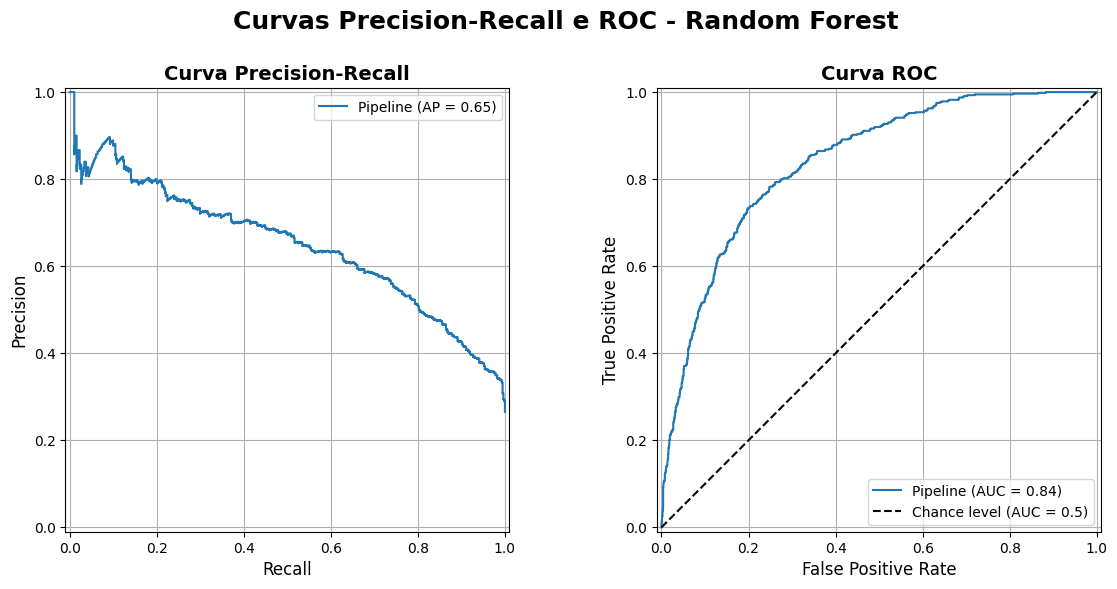

In [38]:
# Plota as curvas Precision-Recall e ROC
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(top=0.85)
fig.suptitle(
            'Curvas Precision-Recall e ROC - Random Forest',
            fontsize=18,
            fontweight='bold'
            )

# Plota a curva Precision-Recall
plot_precision_recall_from_estimator(
    estimator=rf_pipeline,
    X=X_test,
    y=y_test,
    ax=ax[0],
    title='Curva Precision-Recall'
)

# Plota a curva ROC
plot_roc_from_estimator(
    estimator=rf_pipeline,
    X=X_test,
    y=y_test,
    ax=ax[1],
    title='Curva ROC'
)

# Salva a figura
plt.savefig(PLOTS_DIR / 'precision_recall_roc_rf.png', bbox_inches='tight')

# Exibe as curvas
plt.show()

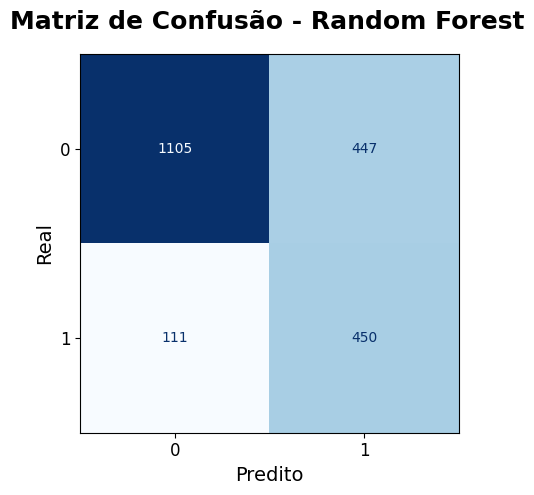

In [39]:
# Plota a matriz de confusão do modelo Random Forest
plot_confusion_matrix_from_estimator(
    estimator=rf_pipeline,
    X=X_test,
    y=y_test,
    title='Matriz de Confusão - Random Forest',
    save_path=PLOTS_DIR / 'conf_matrix_random_forest.png'
)

# Exibe
plt.show()

**Resultados da Avaliação: Random Forest (Test Set)**

| Métrica | Classe 0 (Não) | Classe 1 (Sim - Churn) | Média Ponderada |
| --- | --- | --- | --- |
| **Precision** | 0.91 | **0.50** | 0.80 |
| **Recall** | 0.71 | **0.80** | 0.74 |
| **F1-Score** | 0.80 | **0.62** | 0.75 |
| **Support** | 1552 | **561** | 2113 |


**Análise de Desempenho**

* **Alta Sensibilidade (Recall de 0.80):** Este é o ponto forte do modelo. Ele está identificando corretamente **80%** de todos os clientes que realmente iriam cancelar. Para uma estratégia de retenção, isso é excelente, pois minimiza a perda de clientes por "cegueira" do modelo (Falsos Negativos).
* **O Custo da Precisão (Trade-off):** A precisão de **0.50** na classe de interesse (Yes) indica que, de cada 2 clientes que o modelo aponta como "Risco de Churn", apenas 1 realmente sairia. O outro é um alarme falso. Isso é aceitável se o custo da ação de retenção (ex: enviar um e-mail) for baixo, mas pode ser caro se envolver descontos agressivos.
* **Comparativo de Classes:** O modelo é muito "confiante" para dizer que alguém vai ficar (Precision 0.91), mas mais "ansioso" para dizer que alguém vai sair. Isso sugere que as fronteiras de decisão para a classe minoritária ainda têm sobreposição com a classe majoritária.

### **Importância das Features**

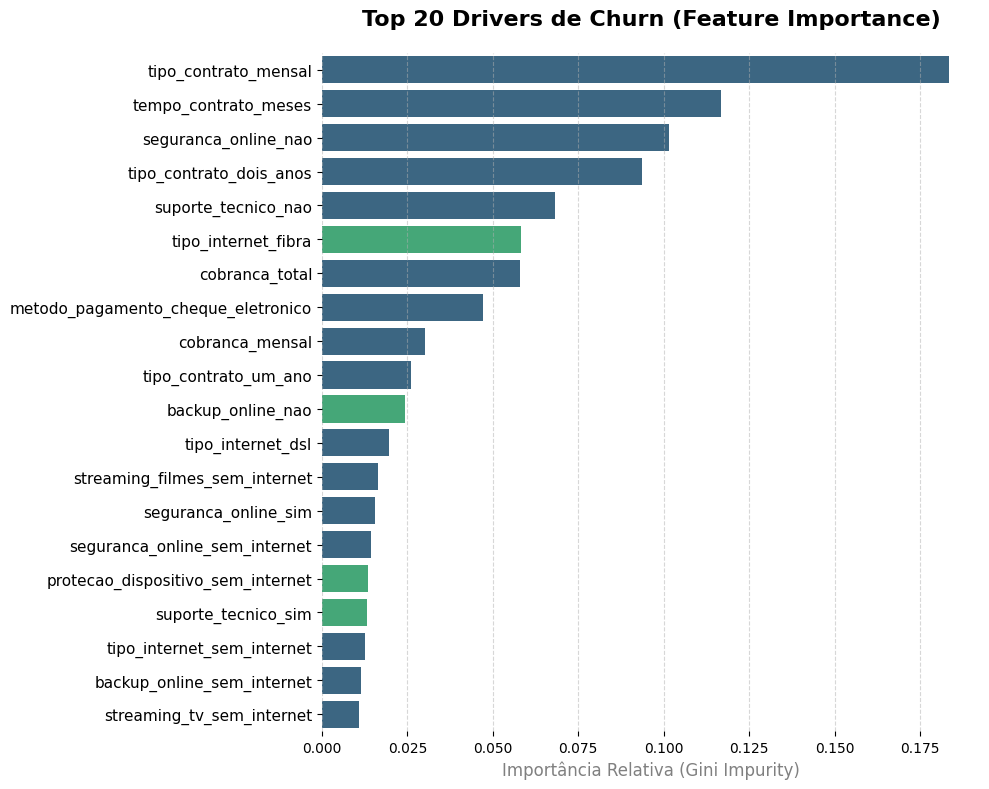

In [45]:
# Acessa os componentes internos do Pipeline
preprocessor_step = rf_pipeline.named_steps['preprocessor']
classifier_step = rf_pipeline.named_steps['classifier']

# Extrai os nomes das features após o pré-processamento
raw_names = preprocessor_step.get_feature_names_out()

# List Comprehension para limpar: quebra no "__" e pega a última parte
clean_names = [name.split('__')[-1] for name in raw_names]

# Monta o DataFrame de Importância das Features
importances = classifier_step.feature_importances_

feature_importances_df = pd.DataFrame({
    'feature': clean_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 20 features mais importantes
top_20_features = feature_importances_df.head(20)

# Plot order
plot_order = top_20_features['feature'].tolist()

# Plota o gráfico de barras horizontal com Seaborn
fig, ax = plt.subplots(figsize=(10, 8))

# Passamos o eixo 'ax' para o Seaborn desenhar dentro dele
sns.barplot(
    data=feature_importances_df.head(20),
    x='importance',
    y='feature',
    order=plot_order,
    palette='viridis',
    hue=y,
    legend=False,
    ax=ax,
    edgecolor='none' # Remove bordas pretas para visual mais limpo
)


ax.set_title('Top 20 Drivers de Churn (Feature Importance)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Importância Relativa (Gini Impurity)', fontsize=12, color='gray')
ax.set_ylabel('')

# Melhorias visuais (Data Ink Ratio)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5) # Grid apenas vertical
sns.despine(left=True, bottom=True) # Remove as bordas do gráfico (caixa)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_importance_rf.png', bbox_inches='tight', dpi=300)
plt.show()

## **Treinamento Final e Serialização do Modelo**

In [ ]:
# Treina o modelo com todos os dados
rf_pipeline.fit(X, y)

# Extrai o classificador treinado do pipeline
classifier_step = rf_pipeline.named_steps['classifier']

try:
    check_is_fitted(classifier_step)
    print("O classificador Random Forest está treinado e pronto para uso.")
except NotFittedError as exc:
    print(f"O classificador Random Forest não está treinado.")
    print(str(exc))

O classificador Random Forest está treinado e pronto para uso.


In [53]:
# Dumpa o pipeline treinado para uso futuro
joblib.dump(rf_pipeline, MODEL_DATA_DIR / MODEL_DATA_PATH)

['/home/joel-victor/Projetos/Hackathon-TelcoCustomerChurn/ml/models/modelo_churn.joblib']